# HMC vs SBI for Analytical Map-Matched Cls

This notebook compares NumPyro NUTS and active-learning SNPE on the same fixed-covariance analytical Cl likelihood. The fiducial datavector is regenerated or loaded at `theta_ej_0 = 2.0` and `nu_theta_ej_M = -0.1`.

The SBI comparison now defaults to the Fisher-whitened MDN run. The raw-parameter and many-small-round NSF runs are kept as diagnostics because their apparent secondary island/tails are neural/proposal artifacts, not physical modes of the fixed-covariance theory likelihood.


In [1]:
import json
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
CANDIDATES = [
    pathlib.Path.cwd(),
    pathlib.Path.cwd() / "notebooks" / "SBI_validate",
    pathlib.Path("/mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/SBI_validate"),
]
THIS_DIR = next(p for p in CANDIDATES if (p / "theory_sbi_utils.py").exists())
if str(THIS_DIR) not in sys.path:
    sys.path.insert(0, str(THIS_DIR))

from theory_sbi_utils import (
    DEFAULT_FIDUCIAL_PATH,
    THEORY_SBI_DIR,
    default_parameter_specs,
    ensure_default_fiducial_product,
    make_inference_theory_vector_function,
    parse_probe_list,
    selected_product_arrays,
    validate_theory_vector,
)
from run_hmc_theory_cls import run_hmc
from run_sbi_theory_cls import run_sbi

plt.rcParams.update({"figure.dpi": 130})


/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PARAM_SPECS = default_parameter_specs()
PROBES = parse_probe_list("gg,gy,gtau,gkappa")
ELL_MIN = None
ELL_MAX = None

# direct is exact-but-expensive; linearized is the practical convergence-test backend.
THEORY_BACKEND = "linearized"
FIDUCIAL_OFFSET = True
SBI_SUMMARY_COMPRESSION = "score"

HMC_RUN_NAME = "joint_gg_gy_gtau_gkappa_linearized"
SBI_RUN_NAME = "joint_gg_gy_gtau_gkappa_linearized_fisher_mdn5"
SBI_DIAGNOSTIC_RUNS = {
    "raw active NSF": "joint_gg_gy_gtau_gkappa_linearized",
    "raw active NSF, discard round 0": "joint_gg_gy_gtau_gkappa_linearized_al_rounds12_nsf",
    "Fisher NSF, SNPE-C": "joint_gg_gy_gtau_gkappa_linearized_fisher_nsf64",
    "Fisher NSF, 8x1024 small rounds": "joint_gg_gy_gtau_gkappa_linearized_fisher_nsf64_8x1024",
    "Fisher MDN5, SNPE-C": "joint_gg_gy_gtau_gkappa_linearized_fisher_mdn5",
    "Fisher MDN5, SNPE-C 2x sims": "joint_gg_gy_gtau_gkappa_linearized_fisher_mdn5_2x",
    "Fisher NSF, first-round loss diagnostic": "joint_gg_gy_gtau_gkappa_linearized_fisher_nsf64_ffl",
}

HMC_RUN_DIR = THEORY_SBI_DIR / HMC_RUN_NAME
SBI_RUN_DIR = THEORY_SBI_DIR / SBI_RUN_NAME
HMC_RUN_DIR.mkdir(parents=True, exist_ok=True)
SBI_RUN_DIR.mkdir(parents=True, exist_ok=True)

FIDUCIAL_PATH = ensure_default_fiducial_product(
    DEFAULT_FIDUCIAL_PATH,
    param_specs=PARAM_SPECS,
    force=False,
)
FIDUCIAL_PATH


PosixPath('/mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/SBI_validate/outputs/theory_sbi/fiducial_thetaej2_nuejm_minus0p1.npz')

In [3]:
selected = selected_product_arrays(FIDUCIAL_PATH, probes=PROBES, ell_min=ELL_MIN, ell_max=ELL_MAX)
product = selected["product"]
meta = product["metadata"]

print("datavector shape:", selected["data_vector"].shape)
print("cov shape:", selected["cov"].shape)
print("cov jitter:", selected["jitter"])
print("fiducial overrides:", meta.get("sim_param_overrides"))
print("theory mode:", meta.get("theory_mode"))
print("paint R200c factor:", meta.get("paint_r200c_factor"))

eig = np.linalg.eigvalsh(selected["cov"])
print("min/max eigenvalue:", eig.min(), eig.max())

datavector shape: (80,)
cov shape: (80, 80)
cov jitter: 0.0
fiducial overrides: {'nu_theta_ej_M': -0.1, 'theta_ej_0': 2.0}
theory mode: map_matched_resolved
paint R200c factor: 8.0
min/max eigenvalue: 1.0627929412300049e-28 5.273740412741185e-12


In [4]:
vector_fn, theory_info = make_inference_theory_vector_function(
    PARAM_SPECS,
    selected["selection"],
    fiducial_vector=selected["data_vector"],
    backend=THEORY_BACKEND,
    fiducial_offset=FIDUCIAL_OFFSET,
    jit_compile=True,
)
checks = validate_theory_vector(vector_fn, selected, PARAM_SPECS)
checks

E0526 03:43:49.925659 1610287 ptx_compiler_helpers.cc:88] *** WARNING *** Invoking ptxas with version 12.5.82, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


[nz consistency] max fractional mismatch = 0.0000e+00, mean = 0.0000e+00  (rtol=0.05)


{'finite_prediction': True,
 'max_abs_diff': 0.0,
 'max_rel_diff': 0.0,
 'median_rel_diff': 0.0,
 'finite_gradient': True,
 'gradient_norm': 0.0}

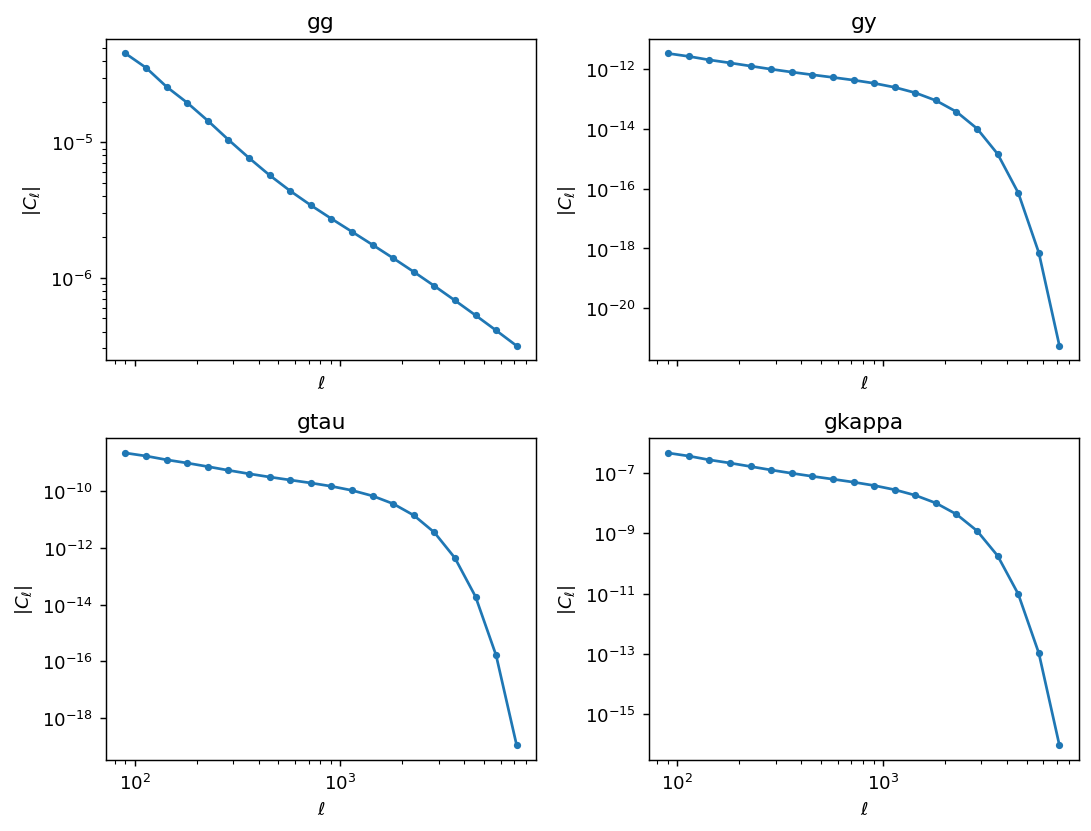

In [5]:
ell = product["ell"]
dv = product["data_vector"]
order = product["spectra_order"]
nell = len(ell)

fig, axes = plt.subplots(2, 2, figsize=(8.5, 6.5), sharex=True)
for ax, spec in zip(axes.ravel(), order):
    i = order.index(spec)
    y = dv[i * nell:(i + 1) * nell]
    ax.loglog(ell, np.abs(y), marker="o", ms=3)
    ax.set_title(spec)
    ax.set_xlabel(r"$\ell$")
    ax.set_ylabel(r"$|C_\ell|$")
fig.tight_layout()

In [6]:
RUN_HMC = False
RUN_SBI = False

if RUN_HMC:
    run_hmc(
        fiducial_path=FIDUCIAL_PATH,
        output_dir=HMC_RUN_DIR,
        probes=PROBES,
        param_specs=PARAM_SPECS,
        ell_min=ELL_MIN,
        ell_max=ELL_MAX,
        num_warmup=4000,
        num_samples=4000,
        num_chains=4,
        max_tree_depth=6,
        dense_mass=True,
        seed=42,
        chain_method="vectorized",
        jit_compile=True,
        fiducial_offset=FIDUCIAL_OFFSET,
        theory_backend=THEORY_BACKEND,
    )

if RUN_SBI:
    run_sbi(
        fiducial_path=FIDUCIAL_PATH,
        output_dir=SBI_RUN_DIR,
        probes=PROBES,
        param_specs=PARAM_SPECS,
        ell_min=ELL_MIN,
        ell_max=ELL_MAX,
        simulations_per_round=[4096, 4096, 8192],
        posterior_samples=30000,
        seed=123,
        hidden_features=64,
        num_transforms=5,
        density_estimator_model="mdn",
        num_components=5,
        num_bins=10,
        training_batch_size=256,
        max_num_epochs=200,
        jit_compile=True,
        fiducial_offset=FIDUCIAL_OFFSET,
        theory_backend=THEORY_BACKEND,
        summary_compression=SBI_SUMMARY_COMPRESSION,
        device="auto",
        discard_prior_samples=True,
        retrain_from_scratch=True,
        force_first_round_loss=False,
        num_atoms=20,
        validation_fraction=0.1,
        learning_rate=5.0e-4,
        parameter_transform="fisher",
    )


In [7]:
hmc_path = HMC_RUN_DIR / "hmc_samples.npz"
sbi_path = SBI_RUN_DIR / "sbi_posterior_samples.npz"

hmc = np.load(hmc_path, allow_pickle=True) if hmc_path.exists() else None
sbi = np.load(sbi_path, allow_pickle=True) if sbi_path.exists() else None

print("HMC run dir:", HMC_RUN_DIR)
print("SBI run dir:", SBI_RUN_DIR)
print("HMC available:", hmc is not None)
print("SBI available:", sbi is not None)
try:
    import torch
    print("torch CUDA available:", torch.cuda.is_available(), "device count:", torch.cuda.device_count())
except Exception as exc:
    print("torch CUDA check failed:", exc)

if (HMC_RUN_DIR / "hmc_diagnostics.json").exists():
    print("HMC diagnostics")
    print(json.dumps(json.loads((HMC_RUN_DIR / "hmc_diagnostics.json").read_text()), indent=2)[:4000])
if (SBI_RUN_DIR / "sbi_diagnostics.json").exists():
    print("SBI diagnostics")
    print(json.dumps(json.loads((SBI_RUN_DIR / "sbi_diagnostics.json").read_text()), indent=2)[:4000])


HMC run dir: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/SBI_validate/outputs/theory_sbi/joint_gg_gy_gtau_gkappa_linearized
SBI run dir: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/SBI_validate/outputs/theory_sbi/joint_gg_gy_gtau_gkappa_linearized_fisher_mdn5
HMC available: True
SBI available: True
torch CUDA available: True device count: 1
HMC diagnostics
{
  "arviz_summary": {
    "ess_bulk": {
      "nu_theta_ej_M": 387.0,
      "theta_ej_0": 385.0
    },
    "ess_tail": {
      "nu_theta_ej_M": 452.0,
      "theta_ej_0": 445.0
    },
    "hdi_3%": {
      "nu_theta_ej_M": -0.162,
      "theta_ej_0": 1.595
    },
    "hdi_97%": {
      "nu_theta_ej_M": -0.022,
      "theta_ej_0": 2.53
    },
    "mcse_mean": {
      "nu_theta_ej_M": 0.002,
      "theta_ej_0": 0.013
    },
    "mcse_sd": {
      "nu_theta_ej_M": 0.001,
      "theta_ej_0": 0.009
    },
    "mean": {
      "nu_theta_ej_M": -0.095,
      "theta_ej_0": 2.033
    },
    "r_hat": {
      "nu_theta_ej_M": 1.

Using 30000 / 30000 SBI samples inside the physical prior.
Removed no burn in
Removed no burn in


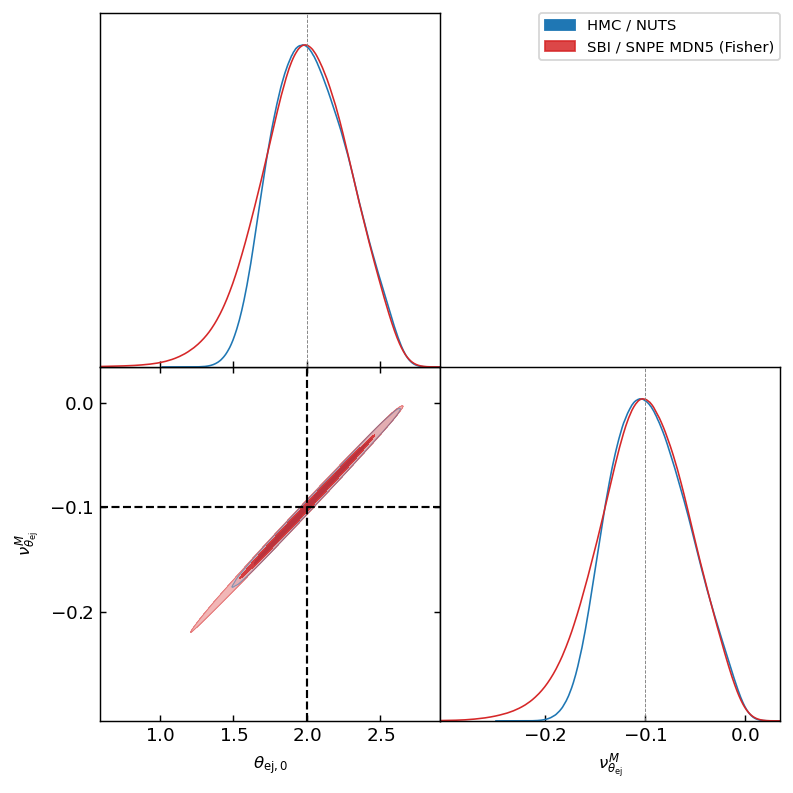

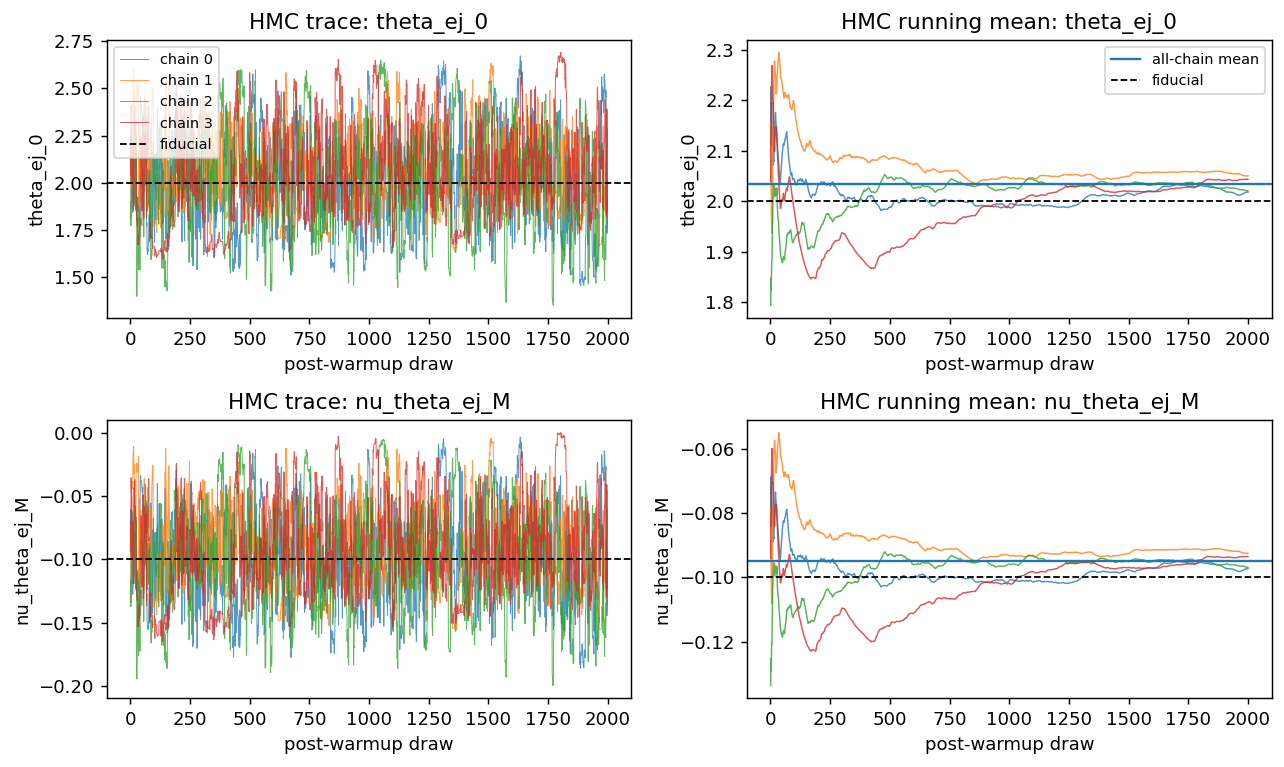

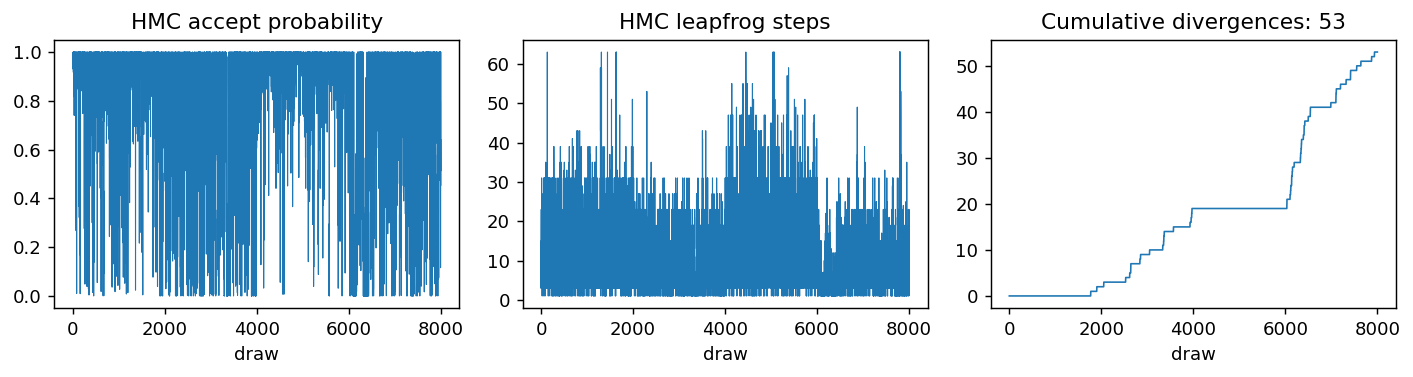

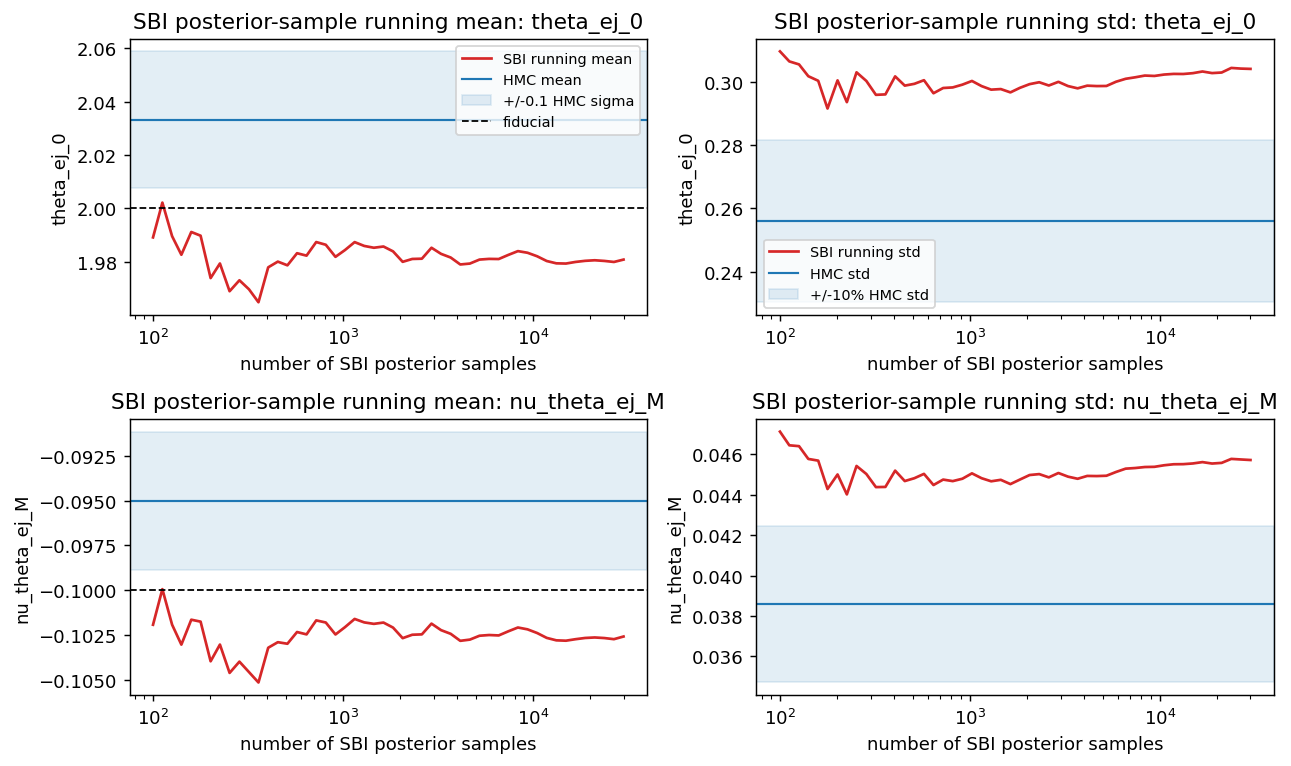

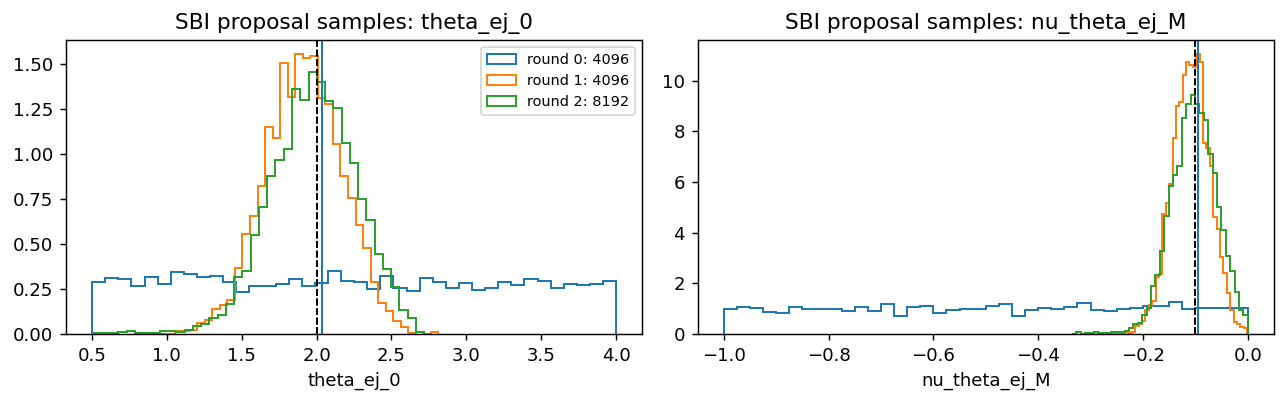

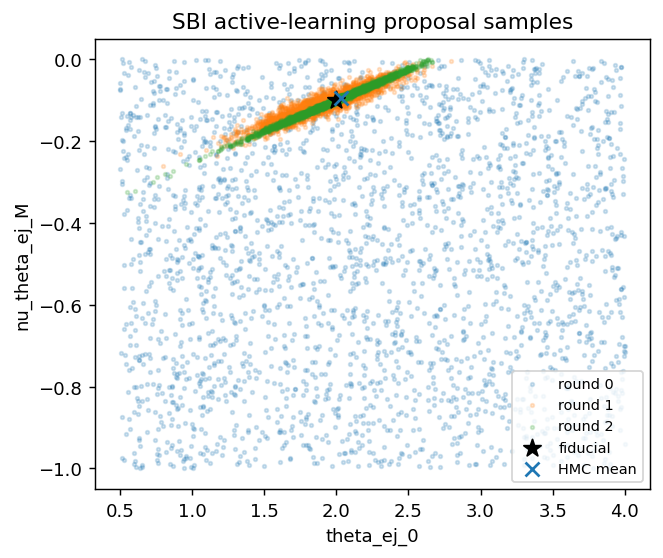

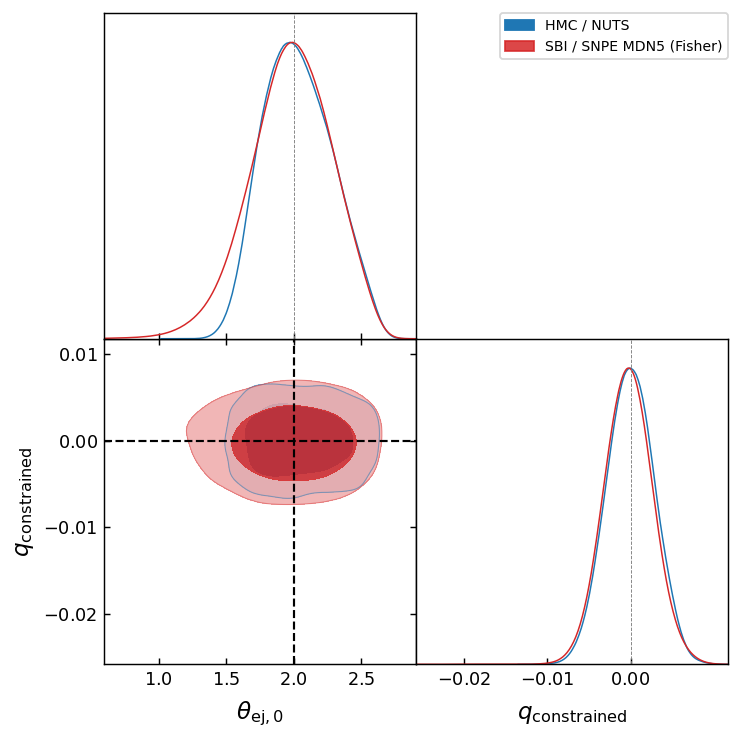

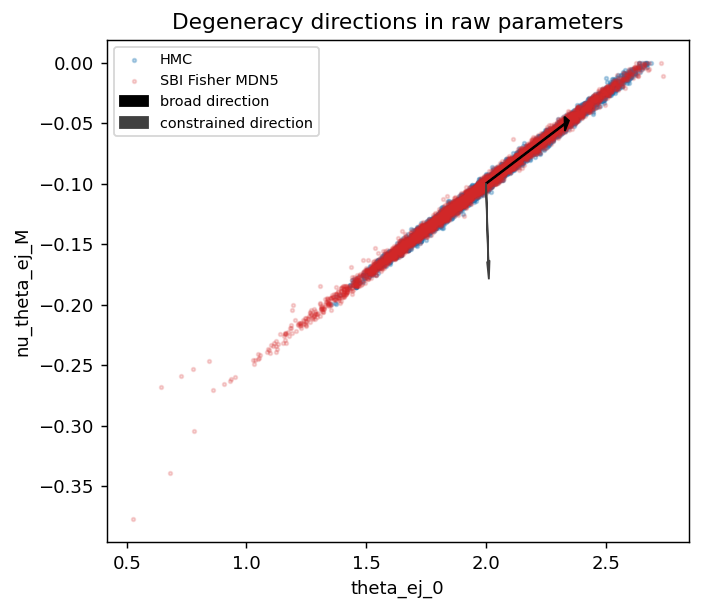

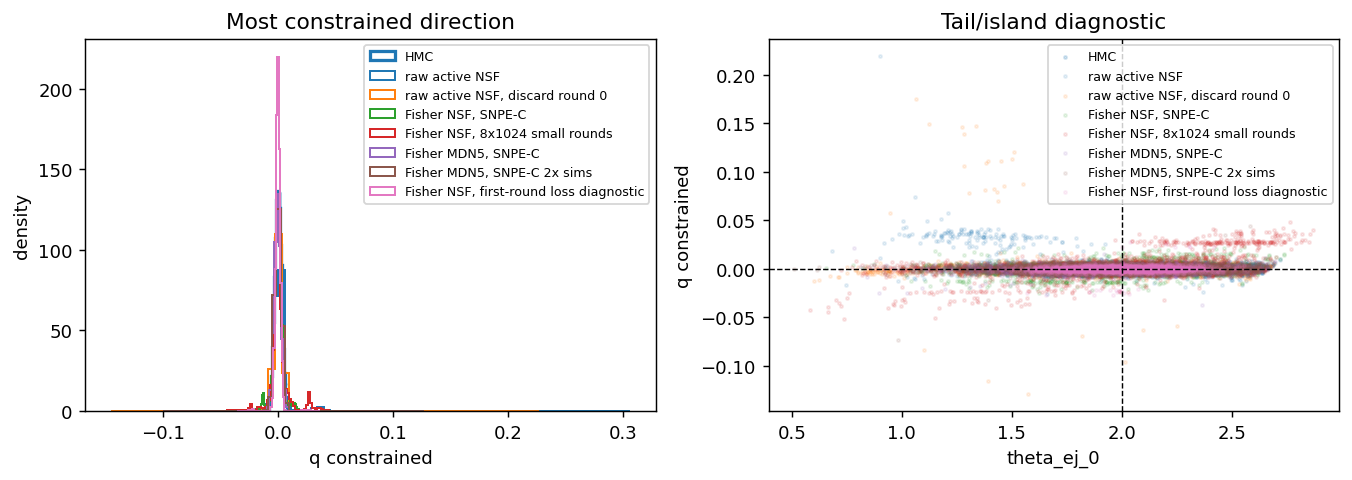

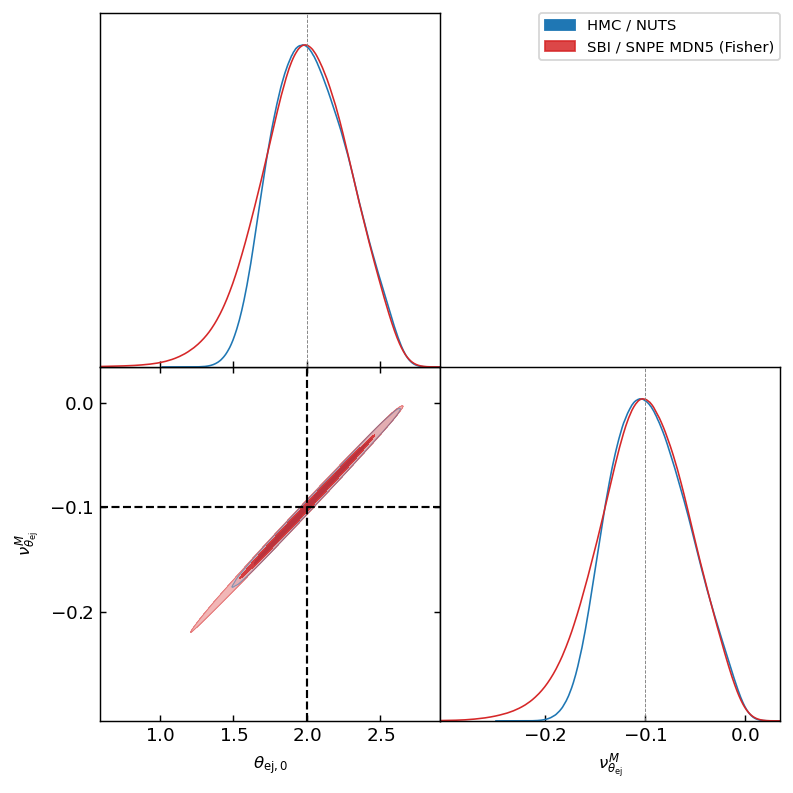

In [16]:
names = [p.name for p in PARAM_SPECS]
labels = [p.label for p in PARAM_SPECS]
fiducial = np.array([p.fiducial for p in PARAM_SPECS], dtype=float)
prior_min = np.array([p.prior_min for p in PARAM_SPECS], dtype=float)
prior_max = np.array([p.prior_max for p in PARAM_SPECS], dtype=float)

def hmc_sample_array(hmc_npz):
    return np.column_stack([hmc_npz[f"samples_{name}"] for name in names])

def filter_prior(samples):
    samples = np.asarray(samples, dtype=float)
    mask = np.all((samples >= prior_min[None, :]) & (samples <= prior_max[None, :]), axis=1)
    return samples[mask], mask

if hmc is not None and sbi is not None:
    from getdist import MCSamples, plots

    hmc_samples = hmc_sample_array(hmc)
    sbi_samples_all = np.asarray(sbi["samples"], dtype=float)
    sbi_samples, sbi_prior_mask = filter_prior(sbi_samples_all)
    print(f"Using {len(sbi_samples)} / {len(sbi_samples_all)} SBI samples inside the physical prior.")

    getdist_settings = {"smooth_scale_1D": 0.35, "smooth_scale_2D": 0.35}
    hmc_gd = MCSamples(
        samples=hmc_samples,
        names=names,
        labels=labels,
        label="HMC / NUTS",
        settings=getdist_settings,
    )
    sbi_gd = MCSamples(
        samples=sbi_samples,
        names=names,
        labels=labels,
        label="SBI / SNPE MDN5 (Fisher)",
        settings=getdist_settings,
    )

    g = plots.get_subplot_plotter(width_inch=6.2)
    g.settings.legend_fontsize = 9
    g.settings.axes_labelsize = 10
    g.triangle_plot(
        [hmc_gd, sbi_gd],
        params=names,
        filled=True,
        legend_labels=["HMC / NUTS", "SBI / SNPE MDN5 (Fisher)"],
        contour_colors=["#1f77b4", "#d62728"],
        markers={name: value for name, value in zip(names, fiducial)},
        marker_args={"color": "black", "lw": 1.2, "ls": "--"},
    )
else:
    print("Run or load both HMC and SBI outputs to make the GetDist overlay.")


In [17]:
if hmc is not None and sbi is not None:
    hmc_samples = hmc_sample_array(hmc)
    sbi_samples, _ = filter_prior(np.asarray(sbi["samples"], dtype=float))
    rows = []
    for i, p in enumerate(PARAM_SPECS):
        hmean, hstd = hmc_samples[:, i].mean(), hmc_samples[:, i].std()
        smean, sstd = sbi_samples[:, i].mean(), sbi_samples[:, i].std()
        rows.append({
            "parameter": p.name,
            "fiducial": p.fiducial,
            "HMC mean": hmean,
            "HMC std": hstd,
            "SBI mean": smean,
            "SBI std": sstd,
            "mean shift / HMC sigma": (smean - hmean) / hstd,
            "SBI std / HMC std": sstd / hstd,
        })

    try:
        import pandas as pd
        display(pd.DataFrame(rows))
    except Exception:
        for row in rows:
            print(row)
else:
    print("Run or load both HMC and SBI outputs to compare posterior moments.")


,parameter,fiducial,HMC mean,HMC std,SBI mean,SBI std,mean shift / HMC sigma,SBI std / HMC std
0,theta_ej_0,2.0,2.033311,0.255930,1.980728,0.304026,-0.205457,1.187927
1,nu_theta_ej_M,-0.1,-0.095003,0.038571,-0.102589,0.045711,-0.196696,1.185095


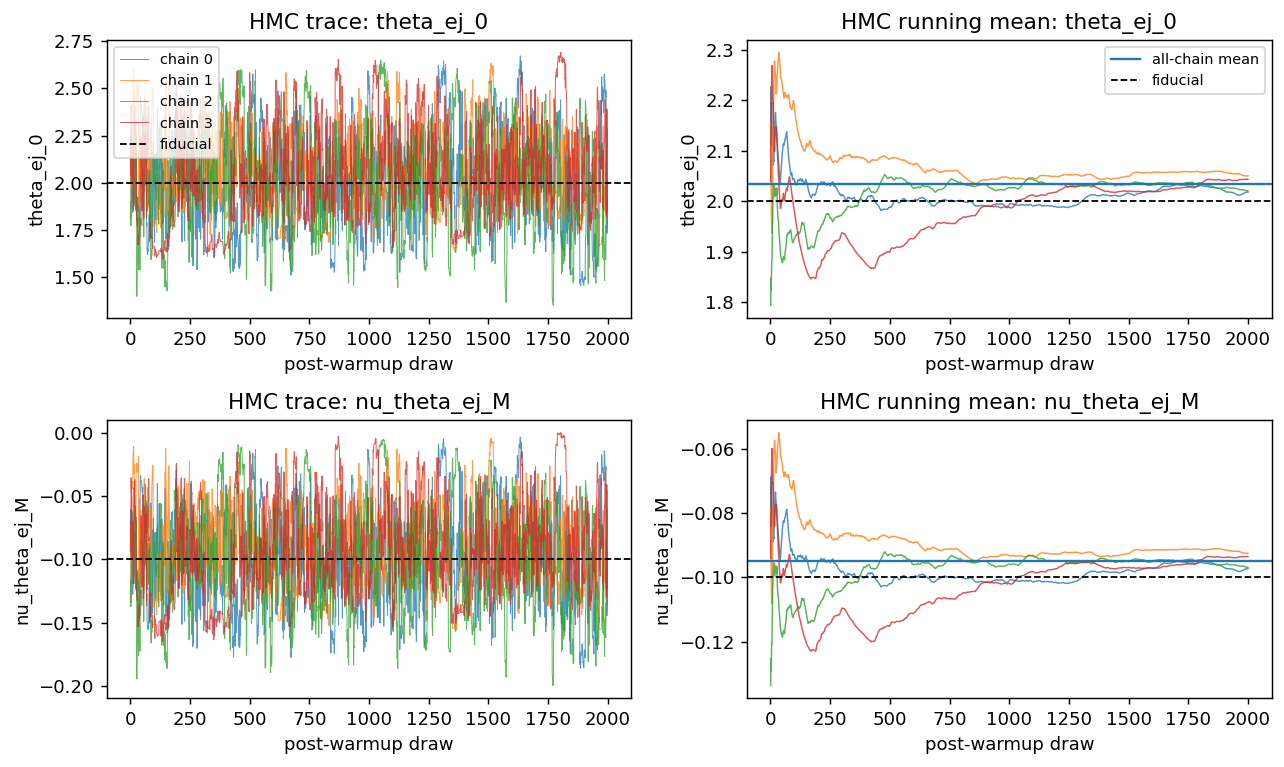

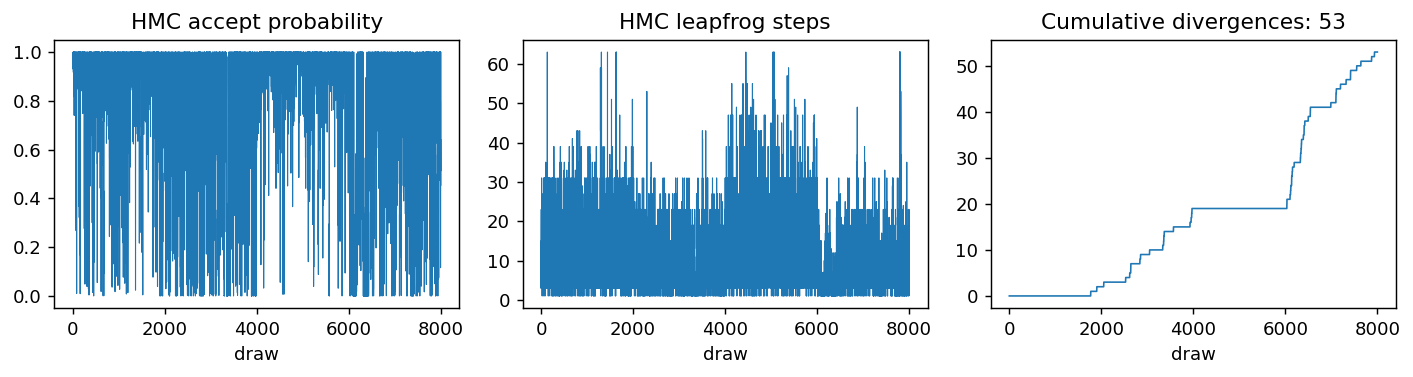

In [18]:
if hmc is not None:
    hmc_samples = np.column_stack([hmc[f"samples_{name}"] for name in names])
    chain_samples = {name: np.asarray(hmc[f"samples_chain_{name}"]) for name in names}
    npar = len(names)
    fig, axes = plt.subplots(npar, 2, figsize=(10, 3.0 * npar), squeeze=False)
    for ip, name in enumerate(names):
        values = chain_samples[name]
        draws = np.arange(1, values.shape[1] + 1)

        ax = axes[ip, 0]
        for ichain, chain in enumerate(values):
            ax.plot(chain, lw=0.55, alpha=0.75, label=f"chain {ichain}" if ip == 0 else None)
        ax.axhline(fiducial[ip], color="black", ls="--", lw=1.0, label="fiducial" if ip == 0 else None)
        ax.set_title(f"HMC trace: {name}")
        ax.set_xlabel("post-warmup draw")
        ax.set_ylabel(name)

        ax = axes[ip, 1]
        running_mean = np.cumsum(values, axis=1) / draws[None, :]
        for ichain, run in enumerate(running_mean):
            ax.plot(draws, run, lw=0.8, alpha=0.8)
        ax.axhline(hmc_samples[:, ip].mean(), color="#1f77b4", lw=1.3, label="all-chain mean")
        ax.axhline(fiducial[ip], color="black", ls="--", lw=1.0, label="fiducial")
        ax.set_title(f"HMC running mean: {name}")
        ax.set_xlabel("post-warmup draw")
        ax.set_ylabel(name)
    axes[0, 0].legend(loc="best", fontsize=8)
    axes[0, 1].legend(loc="best", fontsize=8)
    fig.tight_layout()

    fig, axes = plt.subplots(1, 3, figsize=(11, 3.0))
    if "extra_accept_prob" in hmc.files:
        axes[0].plot(np.asarray(hmc["extra_accept_prob"]).reshape(-1), lw=0.6)
        axes[0].set_title("HMC accept probability")
        axes[0].set_xlabel("draw")
    if "extra_num_steps" in hmc.files:
        axes[1].plot(np.asarray(hmc["extra_num_steps"]).reshape(-1), lw=0.6)
        axes[1].set_title("HMC leapfrog steps")
        axes[1].set_xlabel("draw")
    if "extra_diverging" in hmc.files:
        div = np.asarray(hmc["extra_diverging"]).reshape(-1).astype(int)
        axes[2].plot(np.cumsum(div), lw=0.9)
        axes[2].set_title(f"Cumulative divergences: {div.sum()}")
        axes[2].set_xlabel("draw")
    fig.tight_layout()
else:
    print("No HMC output loaded.")

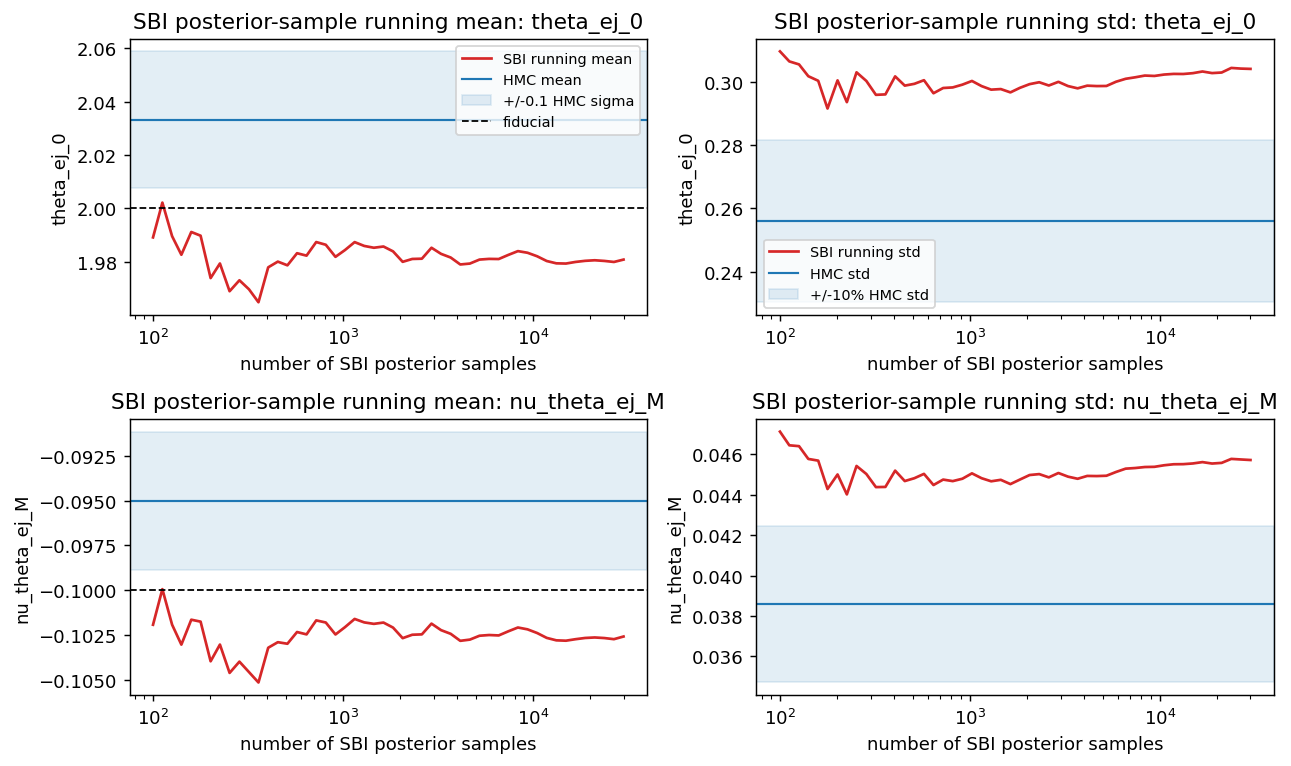

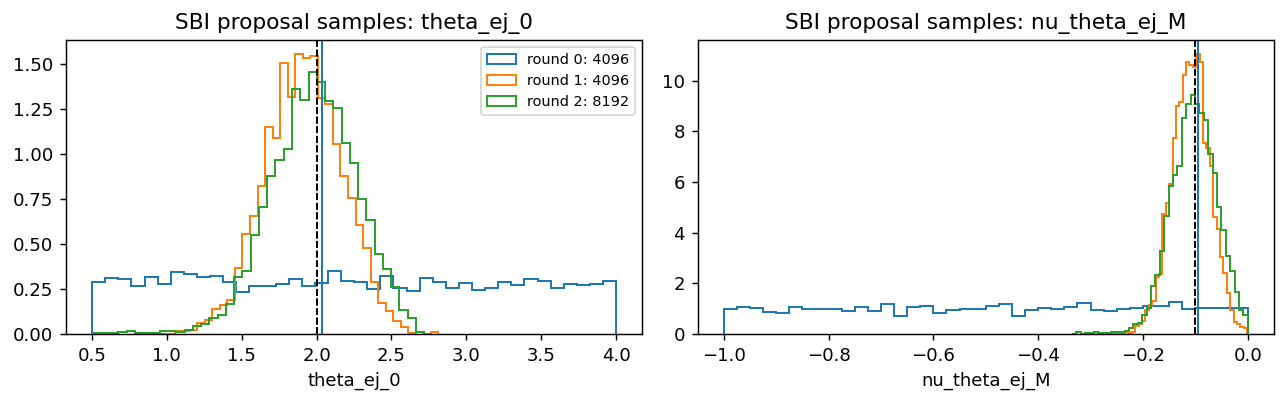

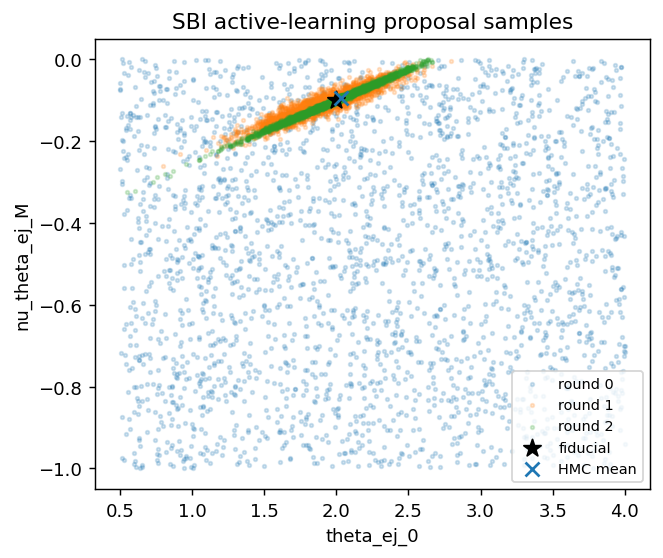

In [19]:
if hmc is not None and sbi is not None:
    hmc_samples = hmc_sample_array(hmc)
    sbi_samples, _ = filter_prior(np.asarray(sbi["samples"], dtype=float))
    n_sbi = len(sbi_samples)
    n_grid = np.unique(np.geomspace(max(20, min(100, n_sbi)), n_sbi, 50).astype(int))
    hmc_mean = hmc_samples.mean(axis=0)
    hmc_std = hmc_samples.std(axis=0)

    fig, axes = plt.subplots(len(names), 2, figsize=(10, 3.0 * len(names)), squeeze=False)
    for ip, name in enumerate(names):
        running_mean = np.array([sbi_samples[:n, ip].mean() for n in n_grid])
        running_std = np.array([sbi_samples[:n, ip].std() for n in n_grid])

        ax = axes[ip, 0]
        ax.plot(n_grid, running_mean, color="#d62728", lw=1.5, label="SBI running mean")
        ax.axhline(hmc_mean[ip], color="#1f77b4", lw=1.2, label="HMC mean")
        ax.axhspan(hmc_mean[ip] - 0.1 * hmc_std[ip], hmc_mean[ip] + 0.1 * hmc_std[ip], color="#1f77b4", alpha=0.12, label="+/-0.1 HMC sigma")
        ax.axhline(fiducial[ip], color="black", ls="--", lw=1.0, label="fiducial")
        ax.set_xscale("log")
        ax.set_title(f"SBI posterior-sample running mean: {name}")
        ax.set_xlabel("number of SBI posterior samples")
        ax.set_ylabel(name)

        ax = axes[ip, 1]
        ax.plot(n_grid, running_std, color="#d62728", lw=1.5, label="SBI running std")
        ax.axhline(hmc_std[ip], color="#1f77b4", lw=1.2, label="HMC std")
        ax.axhspan(0.9 * hmc_std[ip], 1.1 * hmc_std[ip], color="#1f77b4", alpha=0.12, label="+/-10% HMC std")
        ax.set_xscale("log")
        ax.set_title(f"SBI posterior-sample running std: {name}")
        ax.set_xlabel("number of SBI posterior samples")
        ax.set_ylabel(name)
    axes[0, 0].legend(loc="best", fontsize=8)
    axes[0, 1].legend(loc="best", fontsize=8)
    fig.tight_layout()

    round_paths = sorted(SBI_RUN_DIR.glob("sbi_round*_simulations.npz"))
    if round_paths:
        fig, axes = plt.subplots(1, len(names), figsize=(5.0 * len(names), 3.2), squeeze=False)
        for iround, path in enumerate(round_paths):
            theta_round = np.load(path)["theta"]
            for ip, name in enumerate(names):
                axes[0, ip].hist(theta_round[:, ip], bins=40, density=True, histtype="step", lw=1.1, label=f"round {iround}: {len(theta_round)}")
                axes[0, ip].axvline(fiducial[ip], color="black", ls="--", lw=1.0)
                axes[0, ip].axvline(hmc_mean[ip], color="#1f77b4", lw=1.0)
                axes[0, ip].set_title(f"SBI proposal samples: {name}")
                axes[0, ip].set_xlabel(name)
        axes[0, 0].legend(loc="best", fontsize=8)
        fig.tight_layout()

        if len(names) == 2:
            fig, ax = plt.subplots(figsize=(5.2, 4.4))
            rng = np.random.default_rng(1234)
            for iround, path in enumerate(round_paths):
                theta_round = np.load(path)["theta"]
                keep = np.arange(len(theta_round))
                if len(keep) > 2500:
                    keep = rng.choice(keep, size=2500, replace=False)
                ax.scatter(theta_round[keep, 0], theta_round[keep, 1], s=4, alpha=0.20, label=f"round {iround}")
            ax.scatter([fiducial[0]], [fiducial[1]], marker="*", s=100, color="black", label="fiducial")
            ax.scatter([hmc_mean[0]], [hmc_mean[1]], marker="x", s=60, color="#1f77b4", label="HMC mean")
            ax.set_xlabel(names[0])
            ax.set_ylabel(names[1])
            ax.set_title("SBI active-learning proposal samples")
            ax.legend(loc="best", fontsize=8)
            fig.tight_layout()
else:
    print("Need both HMC and SBI outputs for SBI sample diagnostics.")


## Degeneracy Direction

The HMC covariance is diagonalized below. The narrow eigenvector is the most constrained combination of `theta_ej_0` and `nu_theta_ej_M`; this view is more sensitive to spurious islands than the raw parameter triangle.


Most constrained combination centered on fiducial:
q = +0.148634 * (theta_ej_0 - 2) -0.988892 * (nu_theta_ej_M - (-0.1))
Broad degeneracy direction centered on fiducial:
d = +0.988892 * (theta_ej_0 - 2) +0.148634 * (nu_theta_ej_M - (-0.1))
HMC q mean/std: 9.28990977746952e-06 0.0028662774862233866
SBI q mean/std: -0.00030370700153865875 0.0032090500619302294 width ratio: 1.1195880640846398
HMC d mean/std: 0.0336836822243169 0.258804187590114
SBI d mean/std: -0.01944239036936532 0.30742643339531117 width ratio: 1.1878727166586793
Removed no burn in
Removed no burn in


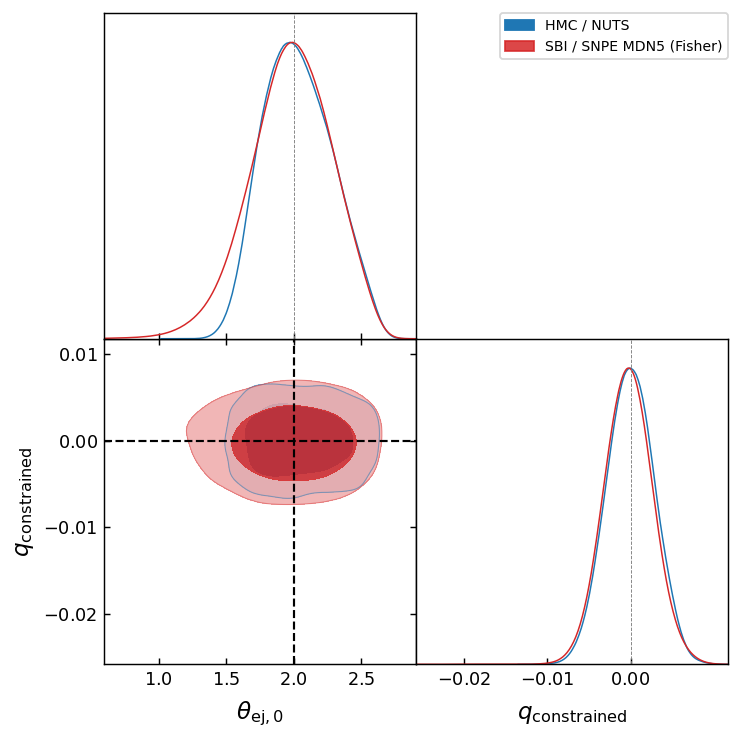

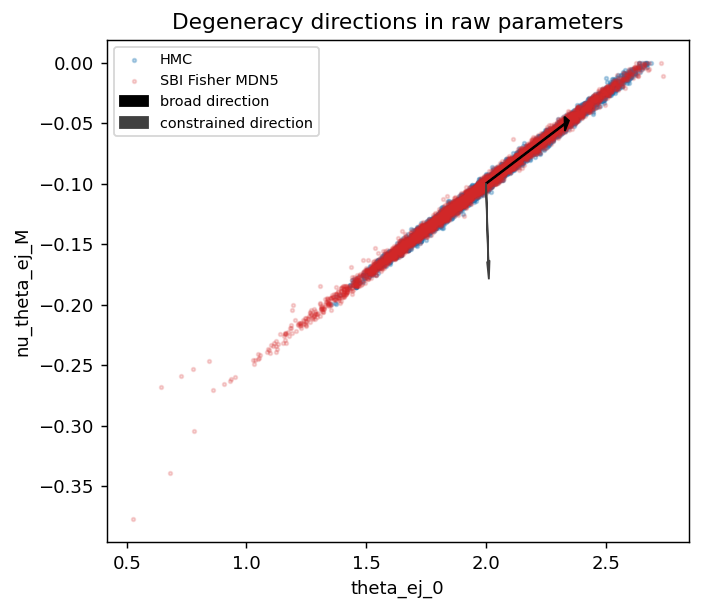

In [20]:
if hmc is not None and sbi is not None:
    from getdist import MCSamples, plots

    hmc_samples = hmc_sample_array(hmc)
    sbi_samples, _ = filter_prior(np.asarray(sbi["samples"], dtype=float))
    cov_hmc = np.cov(hmc_samples.T)
    evals, evecs = np.linalg.eigh(cov_hmc)
    constrained_vec = evecs[:, 0]
    degenerate_vec = evecs[:, 1]
    if constrained_vec[1] > 0:
        constrained_vec = -constrained_vec
    if degenerate_vec[0] < 0:
        degenerate_vec = -degenerate_vec

    def project(samples, vec):
        return (samples - fiducial[None, :]) @ vec

    hmc_q = project(hmc_samples, constrained_vec)
    sbi_q = project(sbi_samples, constrained_vec)
    hmc_d = project(hmc_samples, degenerate_vec)
    sbi_d = project(sbi_samples, degenerate_vec)

    print("Most constrained combination centered on fiducial:")
    print(f"q = {constrained_vec[0]:+.6f} * (theta_ej_0 - {fiducial[0]:.6g}) {constrained_vec[1]:+.6f} * (nu_theta_ej_M - ({fiducial[1]:.6g}))")
    print("Broad degeneracy direction centered on fiducial:")
    print(f"d = {degenerate_vec[0]:+.6f} * (theta_ej_0 - {fiducial[0]:.6g}) {degenerate_vec[1]:+.6f} * (nu_theta_ej_M - ({fiducial[1]:.6g}))")
    print("HMC q mean/std:", hmc_q.mean(), hmc_q.std())
    print("SBI q mean/std:", sbi_q.mean(), sbi_q.std(), "width ratio:", sbi_q.std() / hmc_q.std())
    print("HMC d mean/std:", hmc_d.mean(), hmc_d.std())
    print("SBI d mean/std:", sbi_d.mean(), sbi_d.std(), "width ratio:", sbi_d.std() / hmc_d.std())

    hmc_aug = np.column_stack([hmc_samples[:, 0], hmc_q])
    sbi_aug = np.column_stack([sbi_samples[:, 0], sbi_q])
    aug_names = [names[0], "q_constrained"]
    aug_labels = [labels[0], r"q_{\rm constrained}"]
    settings = {"smooth_scale_1D": 0.35, "smooth_scale_2D": 0.35}
    hmc_aug_gd = MCSamples(samples=hmc_aug, names=aug_names, labels=aug_labels, label="HMC / NUTS", settings=settings)
    sbi_aug_gd = MCSamples(samples=sbi_aug, names=aug_names, labels=aug_labels, label="SBI / SNPE MDN5 (Fisher)", settings=settings)
    g = plots.get_subplot_plotter(width_inch=5.8)
    g.settings.legend_fontsize = 9
    g.triangle_plot(
        [hmc_aug_gd, sbi_aug_gd],
        params=aug_names,
        filled=True,
        contour_colors=["#1f77b4", "#d62728"],
        legend_labels=["HMC / NUTS", "SBI / SNPE MDN5 (Fisher)"],
        markers={aug_names[0]: fiducial[0], aug_names[1]: 0.0},
        marker_args={"color": "black", "lw": 1.2, "ls": "--"},
    )

    fig, ax = plt.subplots(figsize=(5.5, 4.8))
    rng = np.random.default_rng(91)
    for samples, color, label, alpha in [(hmc_samples, "#1f77b4", "HMC", 0.30), (sbi_samples, "#d62728", "SBI Fisher MDN5", 0.18)]:
        keep = np.arange(len(samples))
        if len(keep) > 5000:
            keep = rng.choice(keep, size=5000, replace=False)
        ax.scatter(samples[keep, 0], samples[keep, 1], s=4, alpha=alpha, color=color, label=label)
    scale = 0.35
    ax.arrow(fiducial[0], fiducial[1], scale * degenerate_vec[0], scale * degenerate_vec[1], color="black", width=0.0008, head_width=0.012, length_includes_head=True, label="broad direction")
    ax.arrow(fiducial[0], fiducial[1], 0.08 * constrained_vec[0], 0.08 * constrained_vec[1], color="0.25", width=0.0006, head_width=0.010, length_includes_head=True, label="constrained direction")
    ax.set_xlabel(names[0])
    ax.set_ylabel(names[1])
    ax.set_title("Degeneracy directions in raw parameters")
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
else:
    print("Need both HMC and SBI outputs for the degeneracy-direction plot.")


## SBI Run Comparison

This cell compares the old raw-coordinate NSF, the many-small-round NSF run, the Fisher-whitened MDN run, and the first-round-loss diagnostic. The MDN run is the fastest and best calibrated formal SNPE-C result in this test; the many-small-round NSF is slower and has worse tails.


,run,n inside prior,inside fraction,theta shift / sigma,nu shift / sigma,theta width ratio,nu width ratio,q width ratio,d width ratio
0,raw active NSF,20000,1.000000,-0.359245,-0.404572,1.259910,1.334342,3.113316,1.261217
1,"raw active NSF, discard round 0",30000,1.000000,-0.357721,-0.381193,1.272971,1.309248,2.952163,1.273446
2,"Fisher NSF, SNPE-C",29537,0.984567,-0.217440,-0.213226,1.253707,1.233097,1.653074,1.253196
3,"Fisher NSF, 8x1024 small rounds",30000,1.000000,-0.189119,-0.217306,1.423987,1.331914,3.276444,1.421631
4,"Fisher MDN5, SNPE-C",30000,1.000000,-0.205457,-0.196696,1.187927,1.185095,1.119588,1.187873
5,"Fisher MDN5, SNPE-C 2x sims",30000,1.000000,-0.152747,-0.153647,1.182111,1.177101,1.276910,1.181988
6,"Fisher NSF, first-round loss diagnostic",29987,0.999567,-0.149591,-0.147475,0.726112,0.721978,0.948286,0.725989


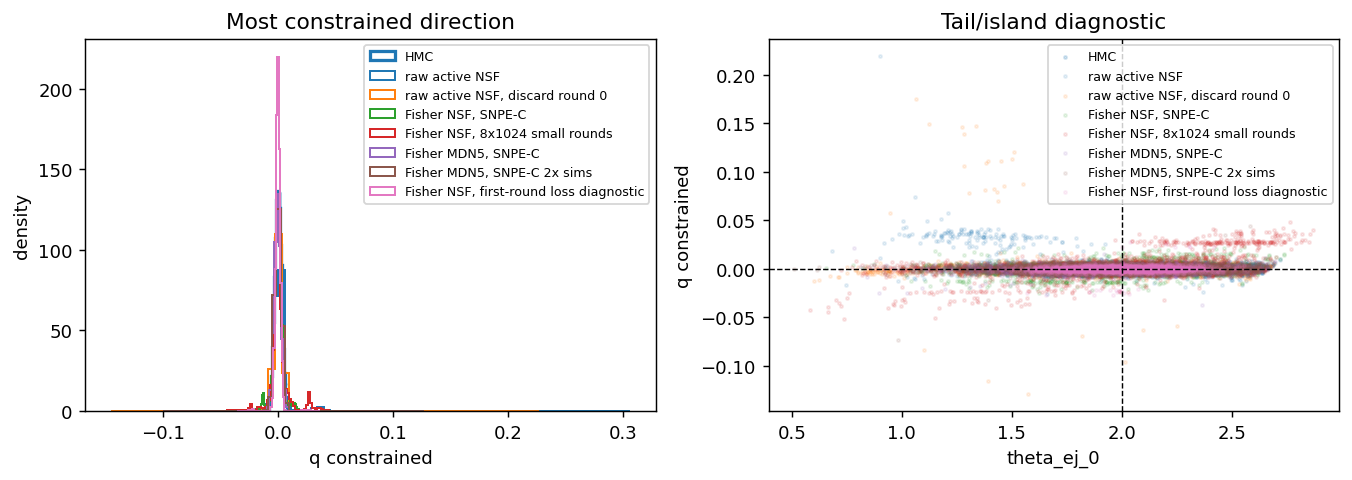

In [21]:
if hmc is not None:
    hmc_samples = hmc_sample_array(hmc)
    cov_hmc = np.cov(hmc_samples.T)
    evals, evecs = np.linalg.eigh(cov_hmc)
    constrained_vec = evecs[:, 0]
    degenerate_vec = evecs[:, 1]
    if constrained_vec[1] > 0:
        constrained_vec = -constrained_vec
    if degenerate_vec[0] < 0:
        degenerate_vec = -degenerate_vec
    hmc_q = (hmc_samples - fiducial[None, :]) @ constrained_vec
    hmc_d = (hmc_samples - fiducial[None, :]) @ degenerate_vec

    rows = []
    loaded_runs = []
    for label, run_name in SBI_DIAGNOSTIC_RUNS.items():
        p = THEORY_SBI_DIR / run_name / "sbi_posterior_samples.npz"
        if not p.exists():
            continue
        samples_all = np.load(p, allow_pickle=True)["samples"]
        samples, mask = filter_prior(samples_all)
        q = (samples - fiducial[None, :]) @ constrained_vec
        d = (samples - fiducial[None, :]) @ degenerate_vec
        rows.append({
            "run": label,
            "n inside prior": len(samples),
            "inside fraction": mask.mean(),
            "theta shift / sigma": (samples[:, 0].mean() - hmc_samples[:, 0].mean()) / hmc_samples[:, 0].std(),
            "nu shift / sigma": (samples[:, 1].mean() - hmc_samples[:, 1].mean()) / hmc_samples[:, 1].std(),
            "theta width ratio": samples[:, 0].std() / hmc_samples[:, 0].std(),
            "nu width ratio": samples[:, 1].std() / hmc_samples[:, 1].std(),
            "q width ratio": q.std() / hmc_q.std(),
            "d width ratio": d.std() / hmc_d.std(),
        })
        loaded_runs.append((label, samples, q))

    try:
        import pandas as pd
        display(pd.DataFrame(rows))
    except Exception:
        for row in rows:
            print(row)

    if loaded_runs:
        fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
        bins_q = np.linspace(np.percentile(hmc_q, 0.2), np.percentile(hmc_q, 99.8), 45)
        axes[0].hist(hmc_q, bins=bins_q, density=True, histtype="step", lw=1.8, color="#1f77b4", label="HMC")
        for label, samples, q in loaded_runs:
            axes[0].hist(q, bins=60, density=True, histtype="step", lw=1.1, label=label)
        axes[0].set_xlabel("q constrained")
        axes[0].set_ylabel("density")
        axes[0].set_title("Most constrained direction")
        axes[0].legend(fontsize=7)

        rng = np.random.default_rng(7)
        keep_h = rng.choice(len(hmc_samples), size=min(4000, len(hmc_samples)), replace=False)
        axes[1].scatter(hmc_samples[keep_h, 0], hmc_q[keep_h], s=3, alpha=0.18, color="#1f77b4", label="HMC")
        for label, samples, q in loaded_runs:
            keep = rng.choice(len(samples), size=min(4000, len(samples)), replace=False)
            axes[1].scatter(samples[keep, 0], q[keep], s=3, alpha=0.10, label=label)
        axes[1].axhline(0.0, color="black", ls="--", lw=0.8)
        axes[1].axvline(fiducial[0], color="black", ls="--", lw=0.8)
        axes[1].set_xlabel(names[0])
        axes[1].set_ylabel("q constrained")
        axes[1].set_title("Tail/island diagnostic")
        axes[1].legend(fontsize=7)
        fig.tight_layout()
else:
    print("Need HMC output for run comparison.")


In [22]:
import matplotlib
%matplotlib inline
